In [1]:
import nugget  # Main NUGGET package for neutrino detector optimization
import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import sys
# import lognorm from matplotlib
from matplotlib import cm
Lognorm = cm.colors.LogNorm

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
importlib.reload(nugget.losses.fisher_info)  # Reload NUGGET package to ensure latest changes are used
device='cuda:3'
center = [0,0,0]
radius = 600
height = 1000
lightsabre_surrogate = nugget.surrogates.LightSabre.LightSabre(device=device, use_poisson=False, domain_size=1600, particle_mode = 'track')
light_yield_surrogate = lightsabre_surrogate.light_yield_surrogate_batched
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                    device=None, 
                                                    event_type='signal', 
                                                    domain_size=1600, 
                                                    E_min=1e2, 
                                                    E_max=1e8, 
                                                    find_exact_intersection=True,
                                                    random_position_along_ray=False,  
                                                    energy_dist='log_uniform',
                                                    cylinder_center=center,
                                                    cylinder_radius=radius,
                                                    cylinder_height=height,
                                                    uniform_zenith_sampling=True,
                                                    cos_range=torch.tensor([0,1]),
                                                    # point_towards_center=True,
                                                    # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                    )
angular_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
        device=device,
        resolution_type='angular',
        fisher_info_params=['energy', 'direction']
    )
energy_resolution_loss = nugget.losses.fisher_info.WeightedResolutionLoss(
    device=device,
    resolution_type='energy',
    fisher_info_params=['energy', 'direction']
)

In [16]:
num_events = 100000
angular_loss_dicts = {}
energy_loss_dicts = {}
spacing_min = 25
spacing_max = 150
spacing_count = 20

for energy in [2,3,4,5,6]:
    print(f"Running fisher info calculations for energy range: 10^{energy} GeV to 10^{energy+1 if energy < 6 else energy+2} GeV")
    signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
                                                        device=None, 
                                                        event_type='signal', 
                                                        domain_size=1600, 
                                                        E_min=10**energy, 
                                                        E_max=10**(energy+1) if energy < 6 else 10**(energy+2), 
                                                        find_exact_intersection=True,
                                                        random_position_along_ray=False,  
                                                        energy_dist='log_uniform',
                                                        cylinder_center=center,
                                                        cylinder_radius=radius,
                                                        cylinder_height=height,
                                                        uniform_zenith_sampling=True,
                                                        cos_range=torch.tensor([0,1]),
                                                        # point_towards_center=True,
                                                        # cos_range=torch.tensor((np.cos(np.radians(155)),np.cos(np.radians(180))))
                                                        )
    signal_events = signal_sampler.sample_events(num_events=num_events)
    if energy < 6:
        angular_loss_dicts[f'{energy}-{energy+1}'] = []
        energy_loss_dicts[f'{energy}-{energy+1}'] = []
    else:
        angular_loss_dicts[f'{energy}-{energy+2}'] = []
        energy_loss_dicts[f'{energy}-{energy+2}'] = []
    for string_spacing in np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count):
        print(f"Running fisher info calculations for string spacing: {string_spacing}m")
        geometry = nugget.geometries.SpaceString.SpaceString(
                device=device,
                hex_type='hexagonal',
                domain_size=2500,
                dim=3,
                n_strings=61,
                points_per_string=20,
                starting_spacing=string_spacing,
                starting_z_spacing=50
            )
        geom_dict = geometry.initialize_points()
        
        
        loss_params = {
                    'signal_event_params': signal_events,
                    'signal_surrogate_func': light_yield_surrogate,
                    'llr_net': None,
                    'llr_iterations': 1,
                    'skip_zero_response': False,
                    'verbose': True,
                    'jacrev_chunk_size': 50000,
                    'point_chunk_size': 22000,
                    'grad_chunk_size': 7,
                    'llr_autodiff_mode': 'jvp',
                    'use_rich_features': True,
                    'use_patd': False,
                    'use_patd_quadrature': False,
                    't_offset_ns': 0,
                    't_max_ns': 5000,
                    'zero_response_threshold': 0.001,
                    'use_charge_quadrature': False,
                    'charge_center_on_llr_peak': False,
                    'adaptive_grid_retry': True,
                    'adaptive_t_max_floor_ns': 10,
                    'uninformative_fisher_value': 1e-6,
                    'precomputed_fisher_per_string_per_event': None,
                    'recompute_bad_points': False,
                    'empty_cache_after_event': True,
                    'events_per_batch': 100000,
                    }
        ang_loss_dict = angular_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        energy_loss_dict = energy_resolution_loss(
                    geom_dict=geom_dict,
                    **loss_params
                    )
        for key in ang_loss_dict:
            if isinstance(ang_loss_dict[key], torch.Tensor):
                ang_loss_dict[key] = ang_loss_dict[key].detach().cpu()
        for key in energy_loss_dict:
            if isinstance(energy_loss_dict[key], torch.Tensor):
                energy_loss_dict[key] = energy_loss_dict[key].detach().cpu()
        if energy < 6:
            angular_loss_dicts[f'{energy}-{energy+1}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+1}'].append(energy_loss_dict)
        else:
            angular_loss_dicts[f'{energy}-{energy+2}'].append(ang_loss_dict)
            energy_loss_dicts[f'{energy}-{energy+2}'].append(energy_loss_dict)

#     angular_foms.append(1/ang_loss_dict['angular_resolution_loss'])
#     mean_energies.append(torch.median(energy_loss_dict['resolution_per_event']))
#     print(f"String spacing: {string_spacing}m, Angular FOM: {angular_foms[-1]}, Median Energy Resolution: {mean_energies[-1]}")
# angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
# mean_energies = torch.stack(mean_energies).squeeze().cpu().numpy()

Running fisher info calculations for energy range: 10^2 GeV to 10^3 GeV


KeyboardInterrupt: 

In [15]:
angular_loss_dicts['2-3'][1]['resolution_params']

[{'energy': tensor([365.4832]),
  'zenith': tensor([0.5513]),
  'azimuth': tensor([0.6197]),
  'position': tensor([[-430.1176, -418.3287,  281.6906]]),
  'direction': tensor([0.4264, 0.3042, 0.8518])},
 {'energy': tensor([141.7296]),
  'zenith': tensor([0.6402]),
  'azimuth': tensor([5.0487]),
  'position': tensor([[-119.1355,  268.3373, -500.0000]]),
  'direction': tensor([ 0.1971, -0.5639,  0.8020])},
 {'energy': tensor([272.5185]),
  'zenith': tensor([0.2624]),
  'azimuth': tensor([2.4199]),
  'position': tensor([[-461.0544,  211.1488, -500.0000]]),
  'direction': tensor([-0.1947,  0.1714,  0.9658])},
 {'energy': tensor([496.9851]),
  'zenith': tensor([1.4143]),
  'azimuth': tensor([3.1104]),
  'position': tensor([[487.3745, 349.9516,  18.3626]]),
  'direction': tensor([-0.9873,  0.0308,  0.1559])},
 {'energy': tensor([460.9429]),
  'zenith': tensor([0.8782]),
  'azimuth': tensor([2.2110]),
  'position': tensor([[ 421.6213, -311.5019, -500.0000]]),
  'direction': tensor([-0.4597,  0

/tmp/ipykernel_19697/858437195.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  angular_foms.append(np.sqrt(squared_res))


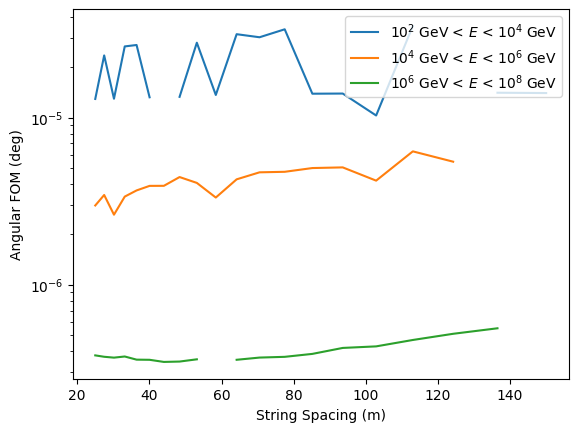

In [19]:
for energy in range(1, 4):    
    angular_foms = []
    for angular_loss_dict in angular_loss_dicts:
        squared_res = 0
        for i, params in enumerate(angular_loss_dict['resolution_params']):
            if params['energy'] >= 10**(2*energy) and params['energy'] < 10**(2*energy+2):
                squared_res += 1/angular_loss_dict['resolution_per_event'][i]**2  
        angular_foms.append(np.sqrt(squared_res))
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], 1/angular_foms, label=fr"$10^{{{2*energy}}}$ GeV < $E$ < $10^{{{2*energy+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.yscale('log')
plt.legend()


In [ ]:
angular_loss_dicts = pickle.load(open("pois_tests/pois_127_angular_loss_dicts_energies.pkl", "rb"))

Energy: 2, best spacing: 21.724014713039995
Energy: 3, best spacing: 30.239907516866793
Energy: 4, best spacing: 21.724014713039995
Energy: 5, best spacing: 20.000000000000004
Energy: 6, best spacing: 45.72260033143283


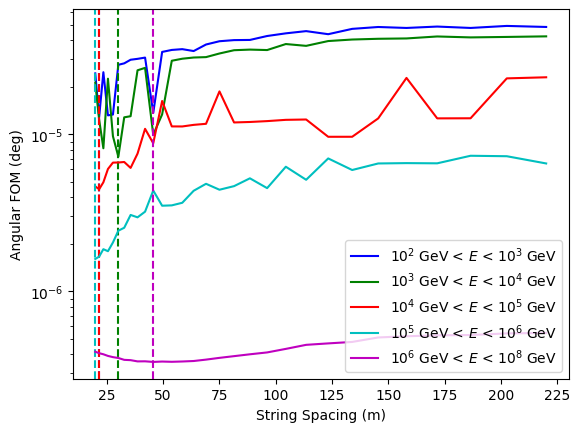

In [14]:
spacing_min = 20
spacing_max = 220
spacing_count = 30
selection_limits = {'zenith': 'horizontal'}
colors = ['b', 'g', 'r', 'c', 'm', 'y']
for energy in range(2,7):
    angular_foms = []
    signal_events = nugget.utils.data_tools.load_signal_events_parquet(f"pois_tests/pois_space_127_signal_events_e{energy}-e{energy+1 if energy < 6 else energy+2}.parquet")
    selection_inds = nugget.utils.data_tools.select_event_indices(
    events=signal_events,
    limits=selection_limits)
    for angular_loss_dict in angular_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        # angular_foms.append(angular_loss_dict['angular_resolution_loss'])
        ang_res = angular_loss_dict['resolution_per_event'][selection_inds]
        angular_foms.append(1 / torch.sqrt(torch.sum(1 / (ang_res[torch.isfinite(ang_res)] ** 2))))
        # angular_foms.append(ang_res[torch.isfinite(ang_res)].median())
    angular_foms = torch.stack(angular_foms).squeeze().cpu().numpy()
    plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], angular_foms, label=fr"10$^{{{energy}}}$ GeV < $E$ < $10^{{{energy+1 if energy < 6 else energy+2}}}$ GeV", color=colors[energy-2])
    # plot the vertical line at the string spacing where the angular FOM is minimized
    plt.axvline(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)][np.argmin(angular_foms)], linestyle='--', color=colors[energy-2])
    print(f"Energy: {energy}, best spacing: {np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)][np.argmin(angular_foms)]}")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.yscale('log')
plt.legend()

In [50]:
# save angular_loss_dicts and energy_loss_dicts to a file
import pickle
# remove resolution_params in dicts to save space
copy_angular_loss_dicts = angular_loss_dicts.copy()
copy_energy_loss_dicts = energy_loss_dicts.copy()
for energy in range(2,7):
    for angular_loss_dict in copy_angular_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        del angular_loss_dict['resolution_params']
    for energy_loss_dict in copy_energy_loss_dicts[f'{energy}-{energy+1}' if energy < 6 else f'{energy}-{energy+2}']:
        del energy_loss_dict['resolution_params']
with open('pois_angular_loss_dicts_energies.pkl', 'wb') as f:
    pickle.dump(copy_angular_loss_dicts, f)

with open('pois_energy_loss_dicts_energies.pkl', 'wb') as f:
    pickle.dump(copy_energy_loss_dicts, f)

In [38]:
angular_foms

array([1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06,
       1.8436865e+06, 1.8436865e+06, 1.8436865e+06, 1.8436865e+06],
      dtype=float32)

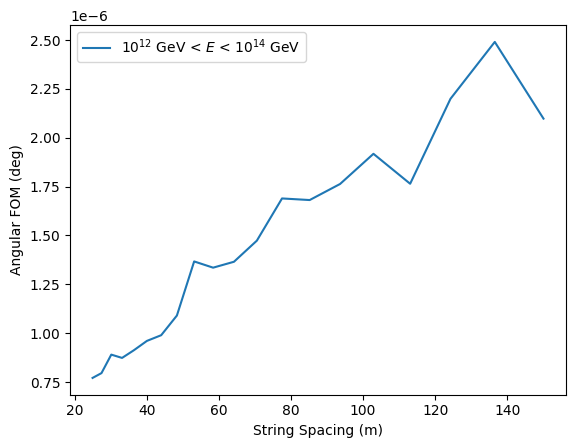

In [17]:
double_e = 2*energy
plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(angular_foms)], 1/angular_foms, label=fr"10$^{{{double_e}}}$ GeV < $E$ < $10^{{{double_e+2}}}$ GeV")
plt.xlabel("String Spacing (m)")
plt.ylabel("Angular FOM (deg)")
plt.legend()

Text(0, 0.5, 'Median Energy Resolution (GeV)')

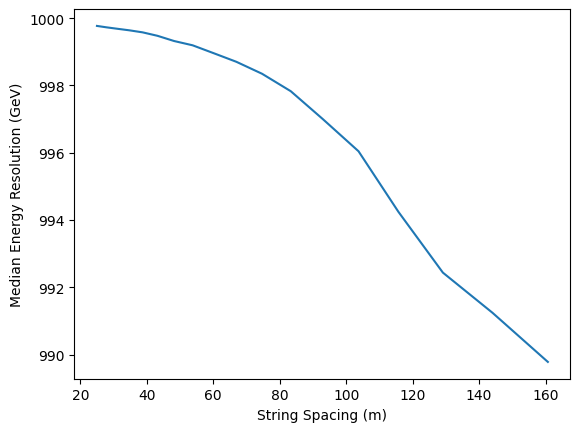

In [29]:
mean_energies = torch.stack(mean_energies).squeeze().cpu().numpy()
plt.plot(np.logspace(np.log10(spacing_min), np.log10(spacing_max), spacing_count)[:len(mean_energies)], mean_energies)
plt.xlabel("String Spacing (m)")
plt.ylabel("Median Energy Resolution (GeV)")

In [ ]:
chargenet = nugget.surrogates.ChargeNet.ChargeNet(
    domain_size=3000,  # Size of the detector domain
    dim=3,  # 3D spatial coordinates
    hidden_dims=[128, 128, 128, 128, 128, 128],  # Neural network architecture
    use_fourier_features=False,  # Use Fourier features for better spatial encoding
    num_parallel_branches=1,  # Multiple branches for ensemble learning
    frequency_scales=[0.1, 0.4],  # Different frequency scales for fourier features
    num_frequencies_per_branch=[64,64],  # Number of Fourier features per branch
    learnable_frequencies=False,  # Fixed frequency features
    dropout_rate=0,  # Regularization
    learning_rate=1e-4,  # Optimizer learning rate
    shared_mlp=False,  # Independent MLPs for each branch
    use_residual_connections=True,  # Skip connections for better training
    signal_noise_scale=0,  # Noise level for signal events
    background_noise_scale=0,  # Noise level for background events
    add_relative_pos=False,  # Whether to include relative position features
    log_scale_ly=True,  # Whether to log-scale the light yield inputs
    norm_pos=True,  # Whether to normalize position inputs
    log_scale_energy=True,  # Whether to log-scale the energy inputs
    add_distance_from_beam=False,  # Whether to include distance from beam as a feature
    reduce_lr_on_plateau=True,  # Reduce learning rate on plateau
    lr_scheduler_patience=15,  # Patience for LR scheduler
    use_rich_features=True,  # Whether to use rich features from the surrogate model
    add_vertex_distance=True,
    rich_rel_pos_mode=True,
    log_charge_scale=4,
    ly_eps=1e-6,
    add_pmt_direction=True
    )
chargenet.load_model('llrnet_models/best_mc_muon_lynet_model_v1.pt')

Building ChargeNet architecture:
  Input dim: 12
  Number of parallel branches: 1
  Shared MLP: False
  Log scale output: True
  Branch 0 MLP: 12 -> 128 -> 128 -> 128 -> 128 -> 128 -> 128
  Final MLP: 128 -> 64 -> 1 (linear)
  Total trainable parameters: 94,209
Model loaded from llrnet_models/best_mc_muon_lynet_model_v1.pt


In [3]:
train_dataloader = chargenet.create_light_yield_parquet_dataloader(
                # parquet_path = 'new_accepted_photons_ly_all.parquet',
                parquet_path = './llrnet_models/mc_muon_lynet_v1_test_samples.parquet',
                geometry_csv_path= '../other/800_40_40_geom.csv',
                num_samples_per_epoch=2048, 
                batch_size=32,
                shuffle=True, 
                num_workers=4, 
                seed=None,
                zero_ly_prob=0.05, 
                zero_ly_value=0.0,
                uniform_energy_zenith=False,
                n_energy_bins=20, 
                n_coszen_bins=20,
                filter_vertex_in_domain=True,
                )

LightYieldParquetDataset: dropped 1489128 row(s) with muon vertex outside domain half-extents [1500.0, 1500.0, 1500.0].


tensor(0.0753)
tensor([ 0.1613,  0.0207, -0.0444, -0.9692, -0.1559,  0.1905,  0.2664,  0.1686,
        -0.9967, -0.4226, -0.6409, -0.6409])


4.819075
tensor(105.0000)


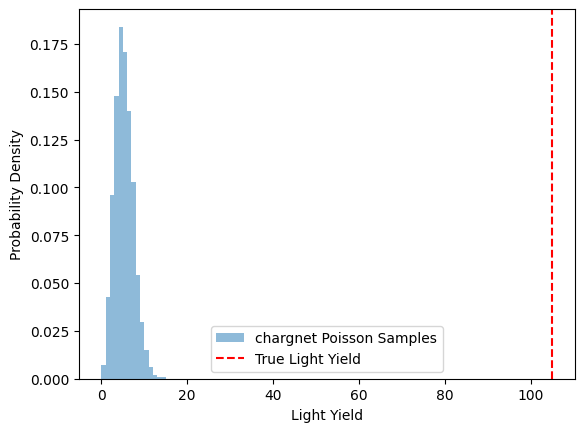

In [83]:
chargenet.is_trained = True
ind = np.random.randint(0, 100)
extra_ind = np.random.randint(0, 32)
count = -1
while count != ind:
    for features, ly in train_dataloader:
        count += 1
        if count == ind:
            break
expected_ly = chargenet.predict(features[extra_ind])
print(expected_ly) # expected light yield
# plot a poisson distribution of the expected light yield with this expected value
poisson_pdf = torch.distributions.Poisson(torch.tensor(expected_ly))
samples = poisson_pdf.sample((10000,))
plt.hist(samples.numpy(), bins=max(samples).int(), density=True, alpha=0.5, label='chargnet Poisson Samples')
true_ly = 10**(ly[extra_ind]*chargenet.log_charge_scale) - 1
print(true_ly) # true light yield
plt.axvline(true_ly, color='r', linestyle='--', label='True Light Yield')
plt.xlabel('Light Yield')
plt.ylabel('Probability Density')
plt.legend()

ValueError: 'x' and 'y' must have the same size

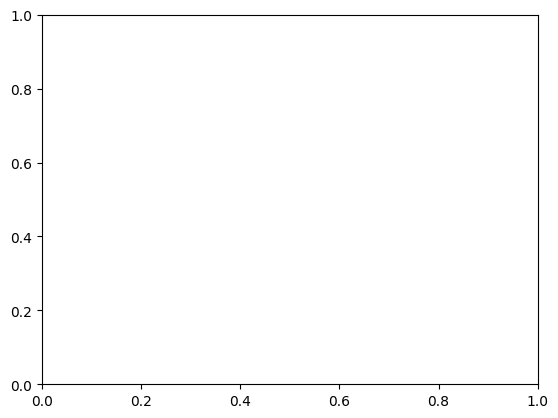

In [ ]:
#plot the expected light yield vs the true light yield for 100 samples from the dataloader with 95% confidence intervals from binned true light yield values
import pandas as pd
expected_lys = []
true_lys = []
for i in range(100):
    features, ly = next(iter(train_dataloader))
    true_ly = 10**(ly*chargenet.log_charge_scale) - 1
    expected_ly = chargenet.predict(features)
    true_lys.extend(true_ly.numpy())
    expected_lys.extend(expected_ly)
plot_df = pd.DataFrame({'true_ly': true_lys, 'expected_ly': expected_lys})
# bin the true light yield values into 20 bins and calculate the mean and 95% confidence intervals of the expected light yield values in each bin



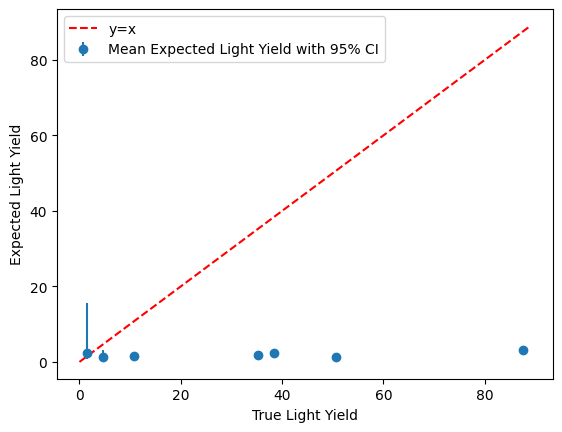

In [90]:
# num_bins = 80
num_bins = np.linspace(0, max(plot_df['true_ly']), 30)
bin_means = plot_df.groupby(pd.cut(plot_df['true_ly'], num_bins))['expected_ly'].median()
bin_ci95_lo = plot_df.groupby(pd.cut(plot_df['true_ly'], num_bins))['expected_ly'].quantile(0.025)
bin_ci95_hi = plot_df.groupby(pd.cut(plot_df['true_ly'], num_bins))['expected_ly'].quantile(0.975)
bin_centers = [interval.mid for interval in bin_means.index]
plt.errorbar(bin_centers, bin_means, yerr=[bin_means - bin_ci95_lo, bin_ci95_hi - bin_means], fmt='o', label='Mean Expected Light Yield with 95% CI')
plt.plot([0, max(plot_df['true_ly'])], [0, max(plot_df['true_ly'])], 'r--', label='y=x')
plt.xlabel('True Light Yield')
plt.ylabel('Expected Light Yield')
plt.legend()